In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
data = pd.read_csv("cropdata_updated.csv")
data.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [ ]:
data.describe()

,MOI,temp,humidity,result
count,16411.000000,16411.000000,16411.000000,16411.000000
mean,43.695387,28.832612,63.487752,0.516178
std,27.160264,9.701465,22.630965,0.621691
min,1.000000,13.000000,15.000000,0.000000
25%,21.000000,20.000000,44.000000,0.000000
50%,41.000000,28.000000,69.200000,0.000000
75%,64.000000,37.000000,84.000000,1.000000
max,100.000000,46.000000,91.000000,2.000000


In [ ]:
data.columns.values

array(['crop ID', 'soil_type', 'Seedling Stage', 'MOI', 'temp',
       'humidity', 'result'], dtype=object)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   Seedling Stage  16411 non-null  object 
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB


In [ ]:
data.shape

(16411, 7)

In [ ]:
len(np.unique(data['crop ID']))

5

In [ ]:
data = data.drop_duplicates()
data

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1
...,...,...,...,...,...,...,...
16406,Chilli,Chalky Soil,Flowering,75,16,88.0,0
16407,Chilli,Chalky Soil,Flowering,76,15,89.0,0
16408,Chilli,Chalky Soil,Flowering,77,14,90.0,0
16409,Chilli,Chalky Soil,Flowering,78,13,91.0,0


In [ ]:
data.columns.to_series().groupby(data.dtypes).groups

{int64: ['MOI', 'temp', 'result'], float64: ['humidity'], object: ['crop ID', 'soil_type', 'Seedling Stage']}

In [ ]:
data.select_dtypes(include='number').skew()

,0
MOI,0.291977
temp,0.078792
humidity,-0.514576
result,0.780788


In [ ]:
data.select_dtypes(include='number').kurt()

,0
MOI,-0.954777
temp,-1.183913
humidity,-1.079741
result,-0.395550


In [ ]:
num_cols = ['MOI', 'temp', 'humidity', 'result']

In [ ]:
features = [col for col in data.columns if col != 'result']
target = 'result'

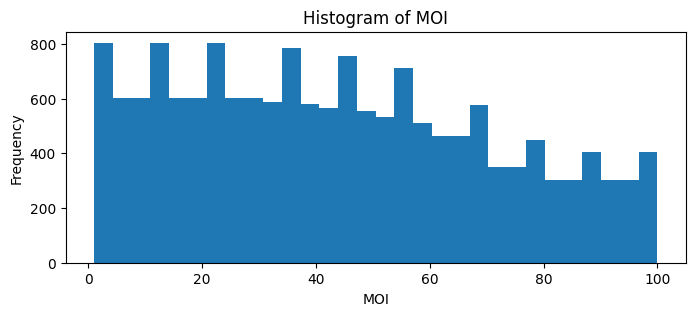

In [ ]:
plt.figure(figsize=(8,3))
plt.hist(data['MOI'], bins=30)
plt.title("Histogram of MOI")
plt.xlabel("MOI")
plt.ylabel("Frequency")
plt.show()

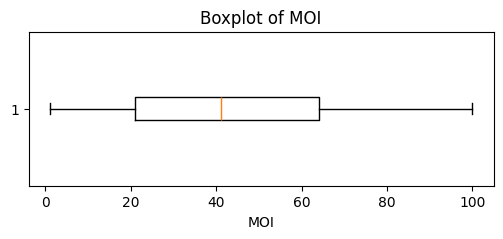

In [ ]:
plt.figure(figsize=(6,2))
plt.boxplot(data['MOI'], vert=False)
plt.title("Boxplot of MOI")
plt.xlabel("MOI")
plt.show()

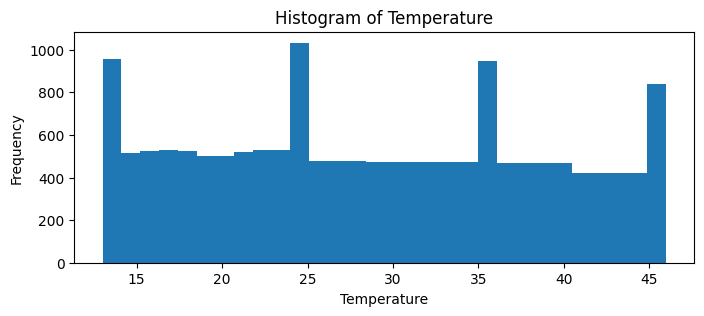

In [ ]:
plt.figure(figsize=(8,3))
plt.hist(data['temp'], bins=30)
plt.title("Histogram of Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()


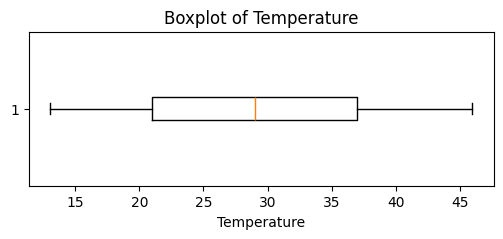

In [ ]:
plt.figure(figsize=(6,2))
plt.boxplot(data['temp'], vert=False)
plt.title("Boxplot of Temperature")
plt.xlabel("Temperature")
plt.show()


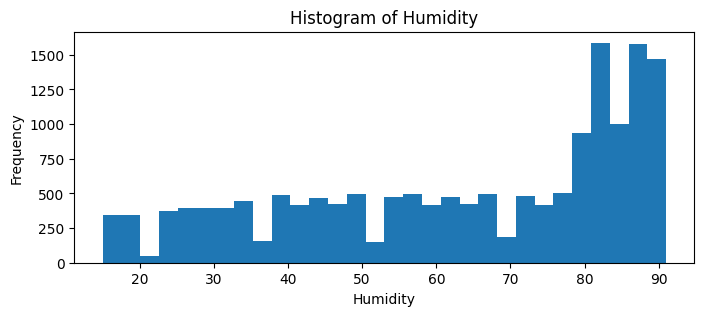

In [ ]:
plt.figure(figsize=(8,3))
plt.hist(data['humidity'], bins=30)
plt.title("Histogram of Humidity")
plt.xlabel("Humidity")
plt.ylabel("Frequency")
plt.show()


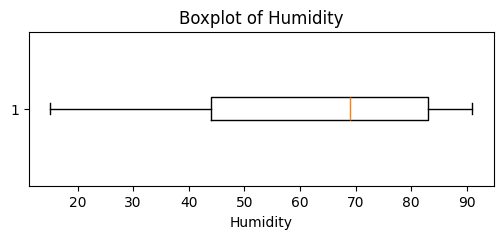

In [ ]:
plt.figure(figsize=(6,2))
plt.boxplot(data['humidity'], vert=False)
plt.title("Boxplot of Humidity")
plt.xlabel("Humidity")
plt.show()


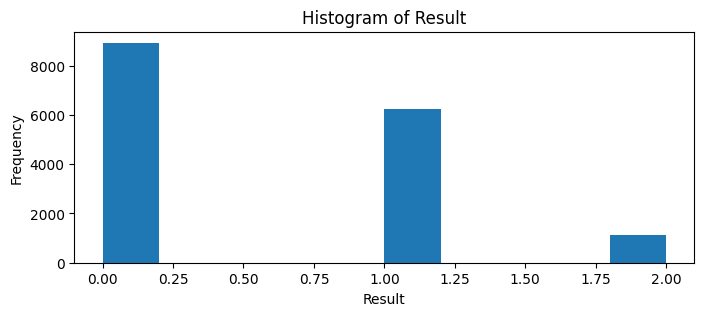

In [ ]:
plt.figure(figsize=(8,3))
plt.hist(data['result'], bins=10)
plt.title("Histogram of Result")
plt.xlabel("Result")
plt.ylabel("Frequency")
plt.show()


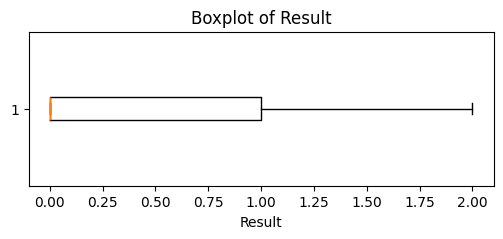

In [ ]:
plt.figure(figsize=(6,2))
plt.boxplot(data['result'], vert=False)
plt.title("Boxplot of Result")
plt.xlabel("Result")
plt.show()


In [ ]:
corr_matrix = data[num_cols].corr()
corr_matrix

,MOI,temp,humidity,result
MOI,1.000000,0.277150,-0.257437,-0.055783
temp,0.277150,1.000000,-0.976147,0.539012
humidity,-0.257437,-0.976147,1.000000,-0.495933
result,-0.055783,0.539012,-0.495933,1.000000


Text(0.5, 1.0, 'Correlation Plot')

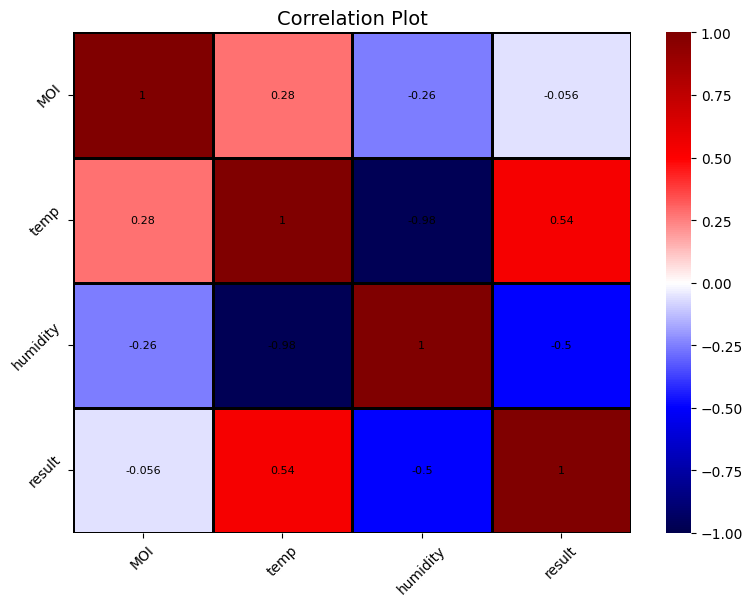

In [ ]:
fig = plt.figure(figsize=(9, 6.5))
sns.heatmap(
    corr_matrix,
    cmap="seismic",
    linewidth=0.75,
    linecolor="black",
    cbar=True,
    vmin=-1,
    vmax=1,
    annot=True,
    annot_kws={"size": 8, "color": "black"}
)

plt.tick_params(labelsize=10, rotation=45)
plt.title("Correlation Plot", size=14)


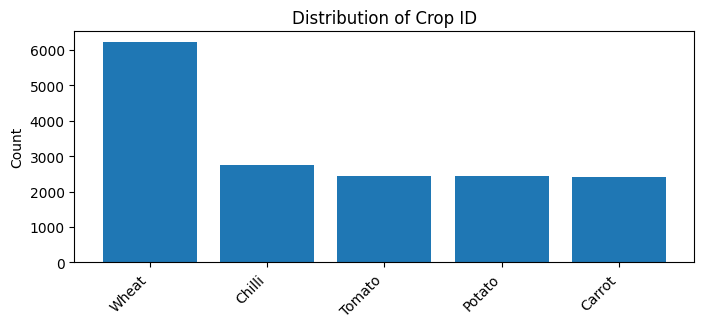

In [ ]:
plt.figure(figsize=(8,3))
plt.bar(data['crop ID'].value_counts().index.astype(str),
        data['crop ID'].value_counts().values)
plt.xticks(rotation=45, ha='right')
plt.title("Distribution of Crop ID")
plt.ylabel("Count")
plt.show()


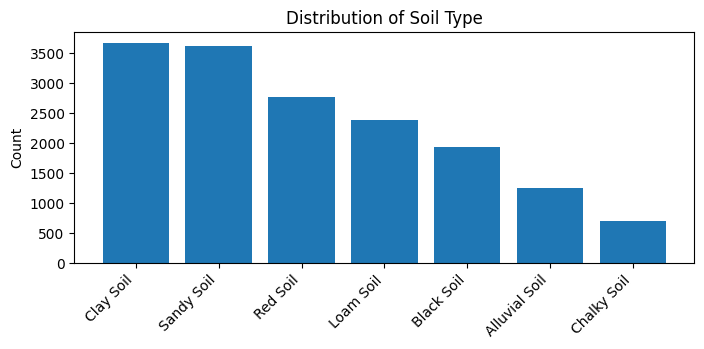

In [ ]:
plt.figure(figsize=(8,3))
plt.bar(data['soil_type'].value_counts().index.astype(str),
        data['soil_type'].value_counts().values)
plt.xticks(rotation=45, ha='right')
plt.title("Distribution of Soil Type")
plt.ylabel("Count")
plt.show()


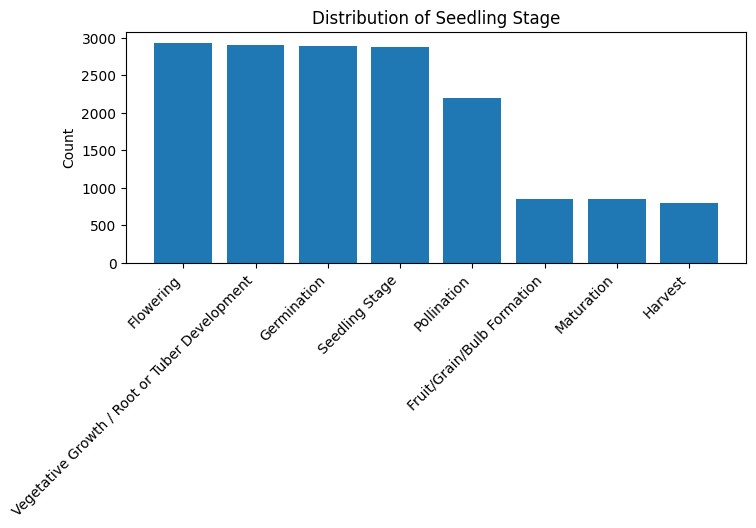

In [ ]:
plt.figure(figsize=(8,3))
plt.bar(data['Seedling Stage'].value_counts().index.astype(str),
        data['Seedling Stage'].value_counts().values)
plt.xticks(rotation=45, ha='right')
plt.title("Distribution of Seedling Stage")
plt.ylabel("Count")
plt.show()


In [ ]:
data.isna().sum()

,0
crop ID,0
soil_type,0
Seedling Stage,0
MOI,0
temp,0
humidity,0
result,0


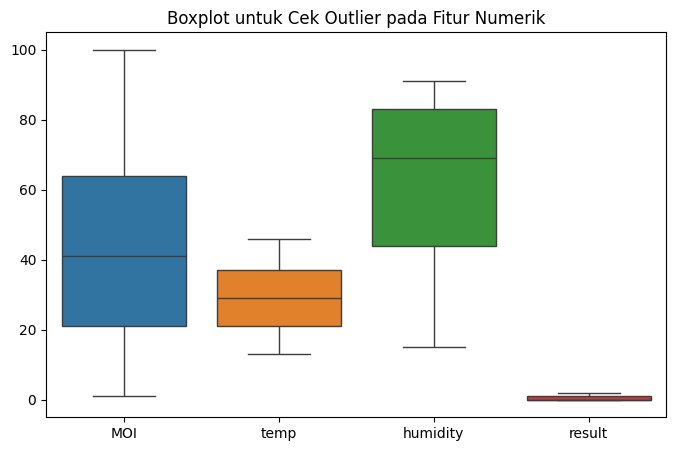

In [ ]:
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(8,5))
sns.boxplot(data=data[numerical_cols])
plt.title("Boxplot untuk Cek Outlier pada Fitur Numerik")
plt.show()


In [ ]:
print("\nDistribusi kelas (counts):")
print(data['result'].value_counts().sort_index())



Distribusi kelas (counts):
result
0    8934
1    6227
2    1122
Name: count, dtype: int64


In [ ]:
data.isnull().sum()

,0
crop ID,0
soil_type,0
Seedling Stage,0
MOI,0
temp,0
humidity,0
result,0


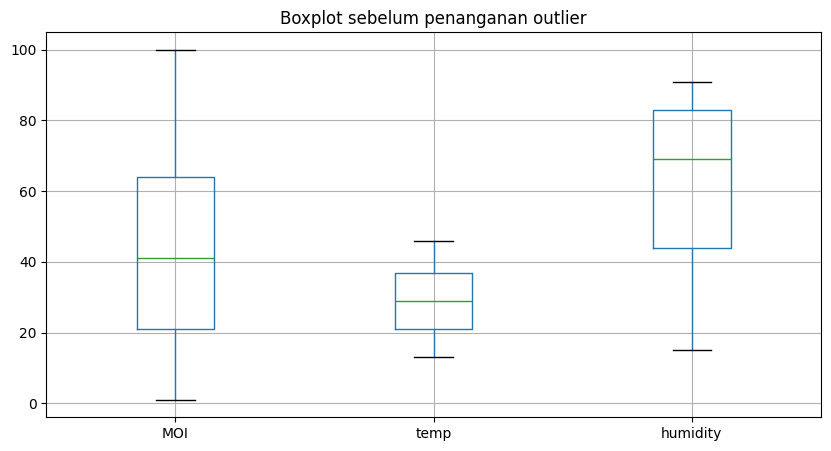

In [ ]:

num_cols = ['MOI', 'temp', 'humidity']

plt.figure(figsize=(10,5))
data[num_cols].boxplot()
plt.title("Boxplot sebelum penanganan outlier")
plt.show()

In [ ]:
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

print("Jumlah data setelah outlier dibersihkan:", data.shape)

Jumlah data setelah outlier dibersihkan: (16283, 7)


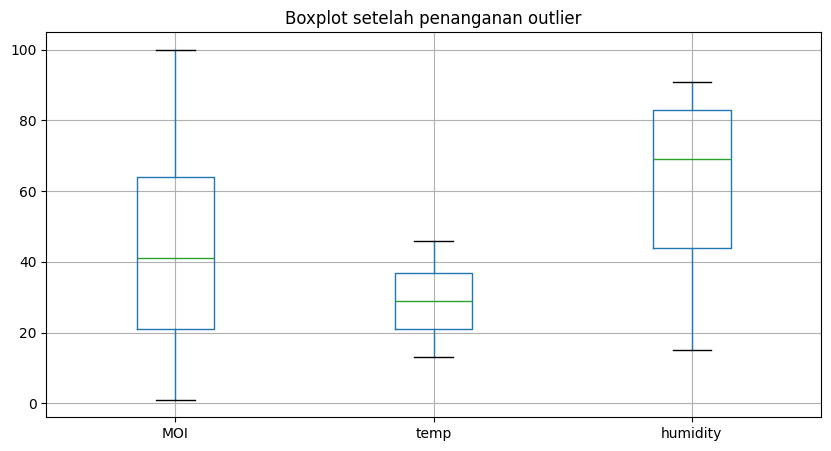

In [ ]:
plt.figure(figsize=(10,5))
data[num_cols].boxplot()
plt.title("Boxplot setelah penanganan outlier")
plt.show()

In [ ]:
categorical_cols = ['crop ID', 'soil_type', 'Seedling Stage']

label_encoder = LabelEncoder()

for col in categorical_cols:
    data[col] = label_encoder.fit_transform(data[col])

data.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,4,1,2,1,25,80.0,1
1,4,1,2,2,26,77.0,1
2,4,1,2,3,27,74.0,1
3,4,1,2,4,28,71.0,1
4,4,1,2,5,29,68.0,1


In [ ]:
raw_data = pd.read_csv("cropdata_updated.csv")

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(raw_data['soil_type'])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)


{'Alluvial Soil': np.int64(0), 'Black Soil': np.int64(1), 'Chalky Soil': np.int64(2), 'Clay Soil': np.int64(3), 'Loam Soil': np.int64(4), 'Red Soil': np.int64(5), 'Sandy Soil': np.int64(6)}


In [ ]:
# cara singkat: jumlah kategori unik per kolom
cols = ['soil_type', 'Seedling Stage', 'MOI', 'temp', 'humidity', 'result']
print(data[cols].nunique())   # menghasilkan Series: nama_kolom -> banyak_kategori_unik


soil_type           7
Seedling Stage      8
MOI               100
temp               34
humidity          106
result              3
dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = ['MOI', 'temp', 'humidity']

scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

print("Sesudah scaling:")
display(data[num_cols].head())

Sesudah scaling:


,MOI,temp,humidity
0,-1.573017,-0.403669,0.737131
1,-1.536249,-0.300496,0.604585
2,-1.499481,-0.197323,0.472040
3,-1.462712,-0.094150,0.339494
4,-1.425944,0.009023,0.206948


In [ ]:
# X_full = data.drop(columns=['result'])
# y = data['result']

# selector = SelectKBest(score_func=mutual_info_classif, k=6)
# selector.fit(X_full, y)

# selected_features = X_full.columns[selector.get_support()]
# print("Fitur terpilih:", list(selected_features))

# X = data[selected_features]


In [ ]:
X_full = data.drop(columns=['result'])
y = data['result']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(score_func=mutual_info_classif, k=6)
selector.fit(X_train, y_train)

selected_features = X_full.columns[selector.get_support()]
print("Fitur terpilih:", list(selected_features))


Fitur terpilih: ['crop ID', 'soil_type', 'Seedling Stage', 'MOI', 'temp', 'humidity']


In [ ]:
X_train = selector.transform(X_train)
X_test  = selector.transform(X_test)


In [ ]:
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )


In [ ]:
# selector = SelectKBest(mutual_info_classif, k=5)
# selector.fit(X_train, y_train)

# X_train = selector.transform(X_train)
# X_test  = selector.transform(X_test)


In [ ]:
print(X_train.shape)
print(X_test.shape)


(13026, 6)
(3257, 6)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtr = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=10,
    min_samples_leaf=5
)

dtr.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, random_state=42)

In [ ]:
dtr.predict(X_test)

array([1, 1, 0, ..., 1, 0, 1])

In [ ]:
acc_dtr = dtr.score(X_test, y_test)
print(acc_dtr)

0.9625422167638932


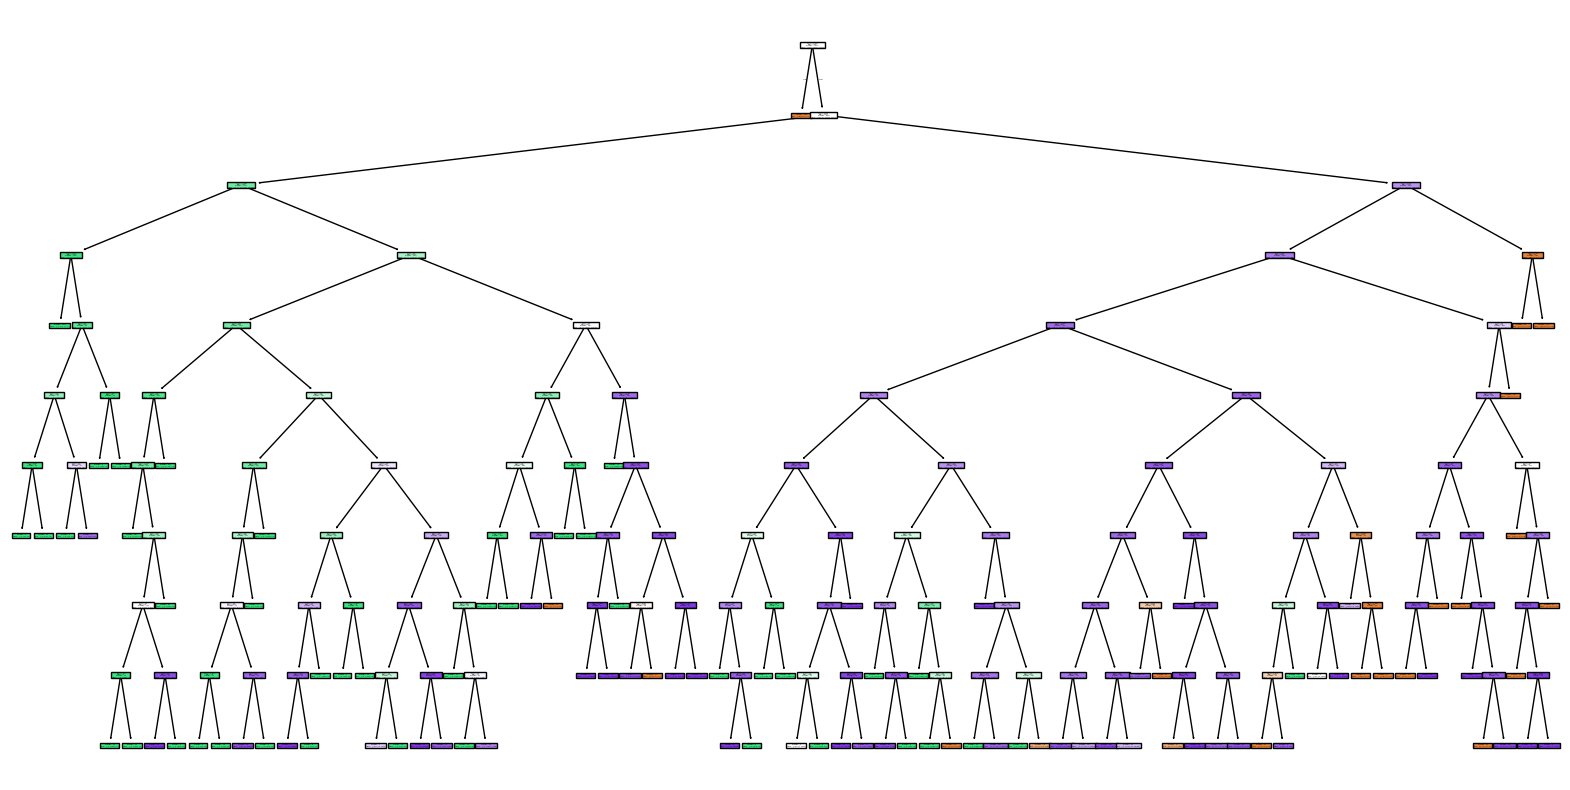

In [ ]:
from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(dtr, filled=True)
plt.show()

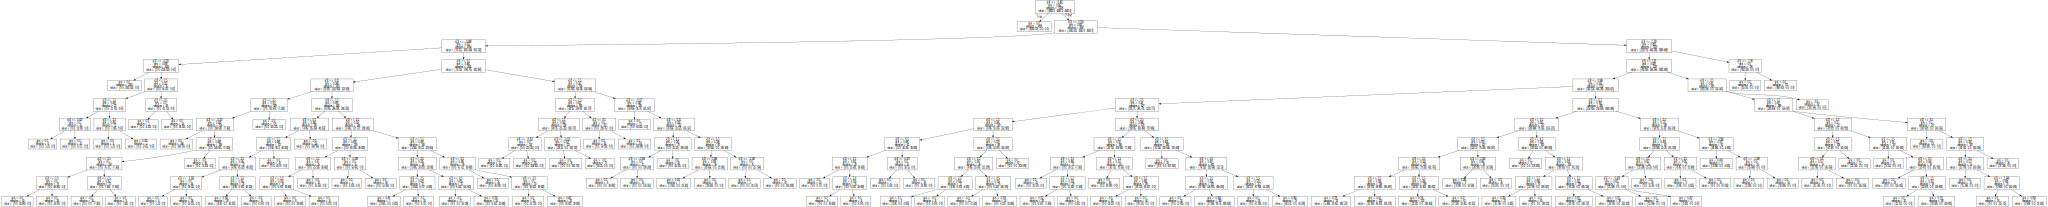

In [ ]:
import graphviz

ddata = tree.export_graphviz(dtr)
graphviz.Source(ddata,filename='gambar.png', format='png')

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
rf.predict(X_test)

array([1, 1, 0, ..., 1, 0, 1])

In [ ]:
# Akruasi Random Forest
acc_rf = rf.score(X_test,y_test)
acc_rf

0.986797666564323

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [ ]:
knn.predict(X_test)

array([1, 1, 0, ..., 1, 0, 1])

In [ ]:
acc_knn = knn.score(X_test,y_test)
acc_knn

0.9508750383788762

In [ ]:
list_model = ['Decision Tree','Random Forest','KNN']
accuracy = [acc_dtr, acc_rf, acc_knn]


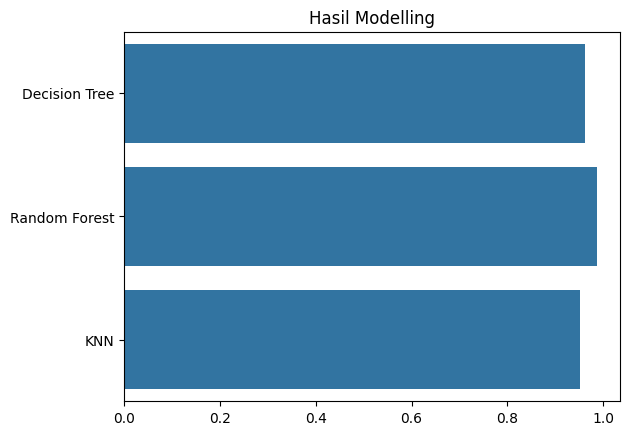

In [ ]:
sns.barplot(x=accuracy,y=list_model)
plt.title('Hasil Modelling')
plt.show()

In [ ]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [ ]:
print(type(model))


<class 'sklearn.tree._classes.DecisionTreeClassifier'>


In [ ]:
y_pred = model.predict(X_test)
print("Akurasi:", accuracy_score(y_test, y_pred))


Akurasi: 0.9941664108074916


In [ ]:
# Import XGBoost Classifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Inisialisasi model XGBoost
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')


# Melatih model
xgb_model.fit(X_train, y_train)


# Melakukan prediksi pada data testing
y_pred_xgb = xgb_model.predict(X_test)


# Menghitung dan menampilkan akurasi
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Akurasi model XGBoost: {accuracy_xgb:.4f}")

Akurasi model XGBoost: 0.9982


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score


# Classification Report for XGBoost
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
precision_xgb = report_xgb['1']['precision']
recall_xgb = report_xgb['1']['recall']
f1_xgb = report_xgb['1']['f1-score']


print(f"\nClassification Report for XGBoost:\n{classification_report(y_test, y_pred_xgb)}")


y_pred_proba_xgb = xgb_model.predict_proba(X_test)

roc_auc_xgb = roc_auc_score(
    y_test,
    y_pred_proba_xgb,
    multi_class='ovr',
    average='macro'
)

print(f"ROC-AUC Score model XGBoost: {roc_auc_xgb:.4f}")



Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1787
           1       1.00      1.00      1.00      1246
           2       0.99      0.98      0.99       224

    accuracy                           1.00      3257
   macro avg       1.00      0.99      0.99      3257
weighted avg       1.00      1.00      1.00      3257

ROC-AUC Score model XGBoost: 0.9999


In [ ]:
type(model)

sklearn.tree._classes.DecisionTreeClassifier

In [ ]:
import pickle

pickle.dump(model, open("model1.pkl", "wb"))


In [ ]:
from google.colab import files
files.download('model1.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
xgb_clf = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    objective='binary:logistic'
)


In [ ]:
type(xgb_model)


xgboost.sklearn.XGBClassifier

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import pickle

cat_cols = ['crop ID', 'soil_type', 'Seedling Stage']
num_cols = ['MOI', 'temp', 'humidity']

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])

xgb_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', xgb_model)
])


In [ ]:
import pandas as pd

X_train = pd.DataFrame(X_train, columns=[
    'crop ID', 'soil_type', 'Seedling Stage',
    'MOI', 'temp', 'humidity'
])

X_test = pd.DataFrame(X_test, columns=[
    'crop ID', 'soil_type', 'Seedling Stage',
    'MOI', 'temp', 'humidity'
])


In [ ]:
xgb_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['crop ID', 'soil_type',
                                                   'Seedling Stage']),
                                                 ('num', 'passthrough',
                                                  ['MOI', 'temp',
                                                   'humidity'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
with open('model.pkl', 'wb') as f:
    pickle.dump(xgb_pipeline, f)
